In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [42]:
df = pd.read_csv("investments_VC.csv", encoding="latin1")

df

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
#retirar colunas irrelevantes#
irrelevant_col = ['permalink', 'homepage_url', 'state_code', 'region', 'founded_month', 'founded_quarter', 'founded_year']
df.drop(columns = irrelevant_col, inplace = True)

In [44]:
initial_rows = len(df)

# Remove rows where ALL values are missing
df.dropna(how='all', inplace=True)

print(f"Rows removed: {initial_rows - len(df)}")

Rows removed: 4856


In [45]:
lista_para_analise = df.select_dtypes(include=['number']).columns.tolist()

# Calcular métricas
total_rows = len(df)
non_zero_counts = (df[lista_para_analise] != 0).sum()
zero_percentages = (df[lista_para_analise] == 0).mean() * 100

# 5. Criar a Tabela de Resumo
summary_df = pd.DataFrame({
    'Coluna': lista_para_analise,
    'Zeros (%)': zero_percentages.map('{:.1f}%'.format),
    'Empresas com valor': non_zero_counts.values
})

# Função para definir a Conclusão baseada nos limites (thresholds)
def definir_conclusao(pct):
    if pct > 99.5: return "Descartável (Ruído puro)"
    if pct > 98.5: return "Candidata a Drop"
    if pct > 95.0: return "Limite (Ainda relevante)"
    return "Útil (Bom volume de dados)"

summary_df['Conclusão'] = zero_percentages.apply(definir_conclusao).values

# Exibir o resultado final
print("TABELA DE ANÁLISE DE VARIÂNCIA (ROUNDS)")
print("-" * 75)
print(summary_df.to_string(index=False))

TABELA DE ANÁLISE DE VARIÂNCIA (ROUNDS)
---------------------------------------------------------------------------
              Coluna Zeros (%)  Empresas com valor                  Conclusão
      funding_rounds      0.0%               49438 Útil (Bom volume de dados)
                seed     72.0%               13840 Útil (Bom volume de dados)
             venture     52.9%               23277 Útil (Bom volume de dados)
 equity_crowdfunding     98.9%                 522           Candidata a Drop
         undisclosed     98.1%                 952   Limite (Ainda relevante)
    convertible_note     98.9%                 557           Candidata a Drop
      debt_financing     91.5%                4225 Útil (Bom volume de dados)
               angel     93.7%                3129 Útil (Bom volume de dados)
               grant     97.7%                1142   Limite (Ainda relevante)
      private_equity     97.2%                1373   Limite (Ainda relevante)
     post_ipo_equity     9

In [46]:

# 3. Criar o Stage Level usando TODOS os rounds (do mais alto para o mais baixo)
def get_full_stage(row):
    if row['round_H'] > 0: return 8
    if row['round_G'] > 0: return 7
    if row['round_F'] > 0: return 6
    if row['round_E'] > 0: return 5
    if row['round_D'] > 0: return 4
    if row['round_C'] > 0: return 3
    if row['round_B'] > 0: return 2
    if row['round_A'] > 0: return 1
    return 0

df['stage_level'] = df.apply(get_full_stage, axis=1)

# Lista de ELIMINAÇÃO 
cols_to_remove = [
    'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

df.drop(columns=[c for c in cols_to_remove if c in df.columns], inplace=True)

print(f"Dataset reduzido para {df.shape[1]} colunas.")
print("A trajetória de todas as empresas foi salva na coluna 'stage_level'.")

Dataset reduzido para 25 colunas.
A trajetória de todas as empresas foi salva na coluna 'stage_level'.


In [47]:

ZERO_THRESHOLD = 0.98  # Drop columns with more than 98% zeros
NULL_THRESHOLD = 0.90  # Drop columns with more than 90% missing values

# Identify columns with too many Zeros
zero_ratio = (df == 0).sum() / len(df)
cols_to_drop_zeros = zero_ratio[zero_ratio > ZERO_THRESHOLD].index.tolist()

# Identify columns with too many Nulls (NaN)
null_ratio = df.isnull().sum() / len(df)
cols_to_drop_nulls = null_ratio[null_ratio > NULL_THRESHOLD].index.tolist()

all_cols_to_drop = list(set(cols_to_drop_zeros + cols_to_drop_nulls))

# DROP
all_cols_to_drop = list(set(cols_to_drop_zeros + cols_to_drop_nulls))

print(f"Dropping {len(cols_to_drop_zeros)} columns due to Zeros: {cols_to_drop_zeros}")
print(f"Dropping {len(cols_to_drop_nulls)} columns due to Nulls: {cols_to_drop_nulls}")

df.drop(columns=all_cols_to_drop, inplace=True)

print("Dataset simplified and saved successfully.")


Dropping 7 columns due to Zeros: ['equity_crowdfunding', 'undisclosed', 'convertible_note', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
Dropping 0 columns due to Nulls: []
Dataset simplified and saved successfully.


In [48]:
df.shape

(49438, 18)

In [49]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 49438 entries, 0 to 49437
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 49437 non-null  object 
 1   category_list        45477 non-null  object 
 2    market              45470 non-null  object 
 3    funding_total_usd   49438 non-null  object 
 4   status               48124 non-null  object 
 5   country_code         44165 non-null  object 
 6   city                 43322 non-null  object 
 7   funding_rounds       49438 non-null  float64
 8   founded_at           38554 non-null  object 
 9   first_funding_at     49438 non-null  object 
 10  last_funding_at      49438 non-null  object 
 11  seed                 49438 non-null  float64
 12  venture              49438 non-null  float64
 13  debt_financing       49438 non-null  float64
 14  angel                49438 non-null  float64
 15  grant                49438 non-null  floa

In [50]:
df.describe()

,funding_rounds,seed,venture,debt_financing,angel,grant,private_equity,stage_level
count,49438.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,49438.000000
mean,1.696205,2.173215e+05,7.501051e+06,1.888157e+06,6.541898e+04,1.628453e+05,2.074286e+06,0.517557
std,1.294213,1.056985e+06,2.847112e+07,1.382046e+08,6.582908e+05,5.612088e+06,3.167231e+07,1.068163
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,2.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,18.000000,1.300000e+08,2.351000e+09,3.007950e+10,6.359026e+07,7.505000e+08,3.500000e+09,8.000000


In [51]:
# 1. Limpar a coluna 'funding_total_usd' (Transformar texto em número real)
# Note que o nome da coluna no seu CSV tem espaços: ' funding_total_usd '
df[' funding_total_usd '] = df[' funding_total_usd '].str.replace(',', '') # Tira as vírgulas
df[' funding_total_usd '] = pd.to_numeric(df[' funding_total_usd '], errors='coerce') # Vira número

# Tratar o Status (Operating, Acquired, Closed)
# Como são poucos valores, vamos transformar em Categoria para economizar RAM
df['status'] = df['status'].astype('category')

# Remover linhas onde o nome da empresa é nulo (Não servem para nada)
df.dropna(subset=['name'], inplace=True)

print(df[' funding_total_usd '].describe())

count    4.090600e+04
mean     1.591291e+07
std      1.686808e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name:  funding_total_usd , dtype: float64


In [52]:
print(df.isnull().sum())


name                       0
category_list           3961
 market                 3968
 funding_total_usd      8531
status                  1314
country_code            5272
city                    6115
funding_rounds             0
founded_at             10884
first_funding_at           0
last_funding_at            0
seed                       0
venture                    0
debt_financing             0
angel                      0
grant                      0
private_equity             0
stage_level                0
dtype: int64


In [53]:
df

,name,category_list,market,funding_total_usd,status,country_code,city,funding_rounds,founded_at,first_funding_at,last_funding_at,seed,venture,debt_financing,angel,grant,private_equity,stage_level
0,#waywire,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,New York,1.0,2012-06-01,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0
1,&TV Communications,|Games|,Games,4000000.0,operating,USA,Los Angeles,2.0,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,40000.0,operating,EST,Tallinn,1.0,2012-10-26,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0
3,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,London,1.0,2011-04-01,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0
4,-R- Ranch and Mine,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,Fort Worth,2.0,2014-01-01,2014-08-17,2014-09-26,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49433,Zzish,|Analytics|Gamification|Developer APIs|iOS|And...,Education,320000.0,operating,GBR,London,1.0,2013-01-28,2014-03-24,2014-03-24,320000.0,0.0,0.0,0.0,0.0,0.0,0
49434,ZZNode Science and Technology,|Enterprise Software|,Enterprise Software,1587301.0,operating,CHN,Beijing,1.0,NaN,2012-04-01,2012-04-01,0.0,1587301.0,0.0,0.0,0.0,0.0,1
49435,Zzzzapp Wireless ltd.,|Web Development|Advertising|Wireless|Mobile|,Web Development,97398.0,operating,HRV,Split,5.0,2012-05-13,2011-11-01,2014-09-10,71525.0,0.0,0.0,0.0,0.0,0.0,0
49436,[a]list games,|Games|,Games,9300000.0,operating,NaN,NaN,1.0,NaN,2011-11-21,2011-11-21,9300000.0,0.0,0.0,0.0,0.0,0.0,0


In [54]:
# Remover linhas duplicadas
rows_before = len(df)
df.drop_duplicates(inplace=True)
rows_after = len(df)

print(f"Linhas removidas por duplicação: {rows_before - rows_after}")
print(f"Shape final: {df.shape}")
print(f"Total de registros únicos: {rows_after}")

Linhas removidas por duplicação: 0
Shape final: (49437, 18)
Total de registros únicos: 49437


In [55]:
# Obter todas as colunas numéricas
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

print(f"Total de variáveis numéricas: {len(numeric_columns)}")
print(f"Variáveis: {numeric_columns}")

df_numeric = df[numeric_columns]

Total de variáveis numéricas: 9
Variáveis: [' funding_total_usd ', 'funding_rounds', 'seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity', 'stage_level']


In [56]:
df_numeric.var()

 funding_total_usd     2.845323e+16
funding_rounds         1.675011e+00
seed                   1.117239e+12
venture                8.106202e+14
debt_financing         1.910089e+16
angel                  4.333554e+11
grant                  3.149617e+13
private_equity         1.003156e+15
stage_level            1.140990e+00
dtype: float64

In [57]:
df

,name,category_list,market,funding_total_usd,status,country_code,city,funding_rounds,founded_at,first_funding_at,last_funding_at,seed,venture,debt_financing,angel,grant,private_equity,stage_level
0,#waywire,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,New York,1.0,2012-06-01,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0
1,&TV Communications,|Games|,Games,4000000.0,operating,USA,Los Angeles,2.0,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,40000.0,operating,EST,Tallinn,1.0,2012-10-26,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0
3,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,London,1.0,2011-04-01,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0
4,-R- Ranch and Mine,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,Fort Worth,2.0,2014-01-01,2014-08-17,2014-09-26,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49433,Zzish,|Analytics|Gamification|Developer APIs|iOS|And...,Education,320000.0,operating,GBR,London,1.0,2013-01-28,2014-03-24,2014-03-24,320000.0,0.0,0.0,0.0,0.0,0.0,0
49434,ZZNode Science and Technology,|Enterprise Software|,Enterprise Software,1587301.0,operating,CHN,Beijing,1.0,NaN,2012-04-01,2012-04-01,0.0,1587301.0,0.0,0.0,0.0,0.0,1
49435,Zzzzapp Wireless ltd.,|Web Development|Advertising|Wireless|Mobile|,Web Development,97398.0,operating,HRV,Split,5.0,2012-05-13,2011-11-01,2014-09-10,71525.0,0.0,0.0,0.0,0.0,0.0,0
49436,[a]list games,|Games|,Games,9300000.0,operating,NaN,NaN,1.0,NaN,2011-11-21,2011-11-21,9300000.0,0.0,0.0,0.0,0.0,0.0,0


In [58]:

df.columns = df.columns.str.strip()
xy = len(df)
print(f"Linhas originais: {len(df)}")
# Remover linhas onde 'funding_total_usd' OU 'market' são nulos
# Estas são as colunas vitais para definir o perfil da startup
df.dropna(subset=['funding_total_usd', 'market'], inplace=True)

print(f"Linhas removidas: {xy - len(df)}")
print(f"Linhas restantes: {len(df)}")

Linhas originais: 49437
Linhas removidas: 11039
Linhas restantes: 38398


In [72]:
# Analyze zeros in df_model
zero_pct = (df_model == 0).mean() * 100
print("Percentage of zeros in each feature:")
print(zero_pct.round(2))

# Check rows with all zeros in funding types
funding_cols = ['seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity']
all_zero_funding = (df_model[funding_cols] == 0).all(axis=1)
print(f"\nRows with all zero funding types: {all_zero_funding.sum()} out of {len(df_model)} ({all_zero_funding.mean()*100:.2f}%)")

# Rows with zero in venture (main funding)
zero_venture = (df_model['venture'] == 0)
print(f"Rows with zero venture funding: {zero_venture.sum()} ({zero_venture.mean()*100:.2f}%)")

Percentage of zeros in each feature:
funding_total_usd      0.00
funding_rounds         0.00
seed                  74.36
venture               30.06
debt_financing       100.00
angel                100.00
grant                100.00
private_equity       100.00
cluster               78.43
dtype: float64

Rows with all zero funding types: 1367 out of 21379 (6.39%)
Rows with zero venture funding: 6426 (30.06%)


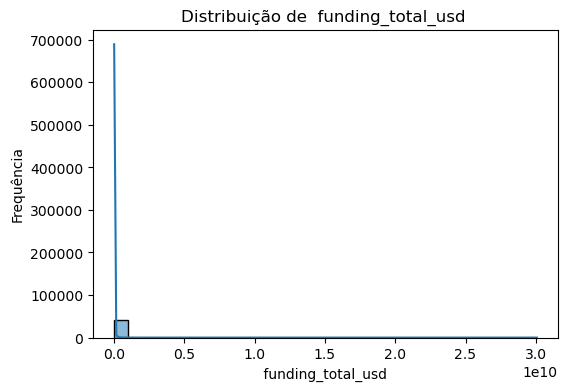

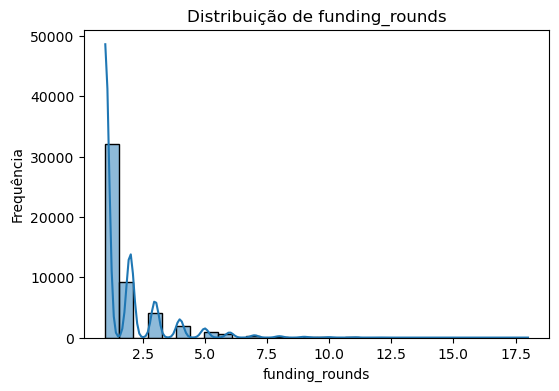

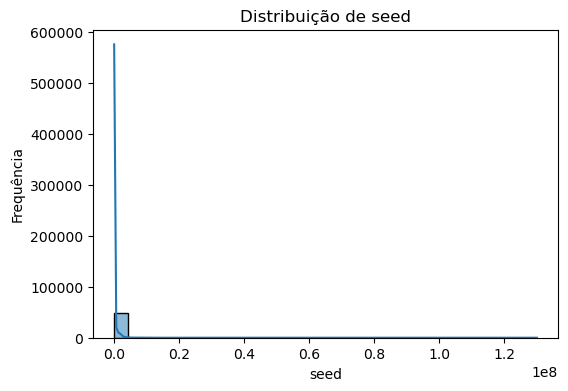

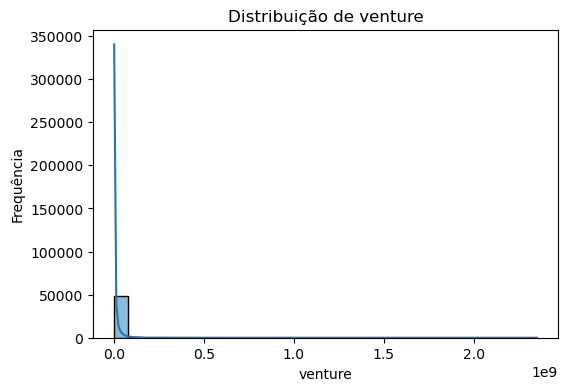

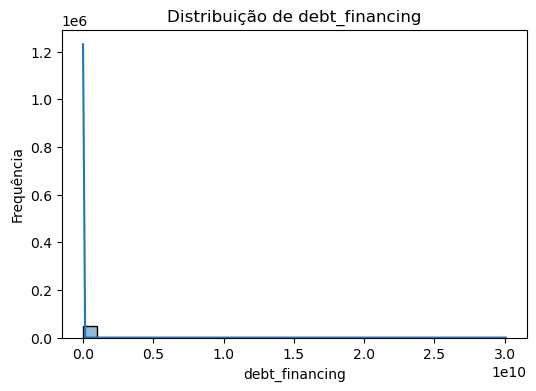

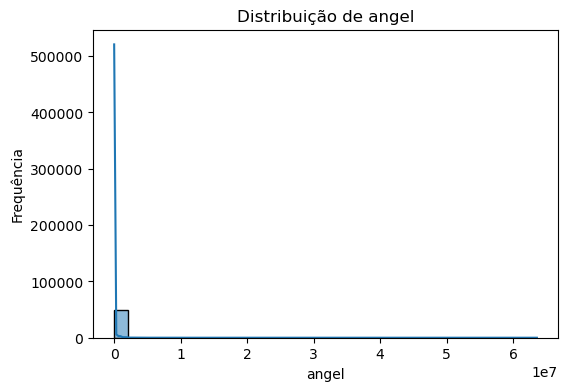

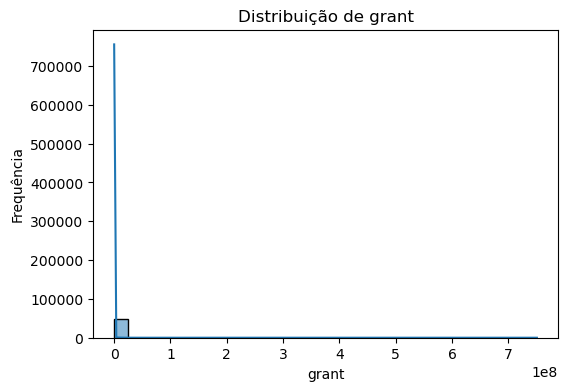

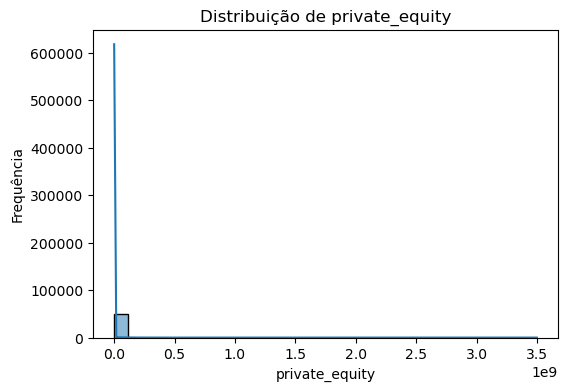

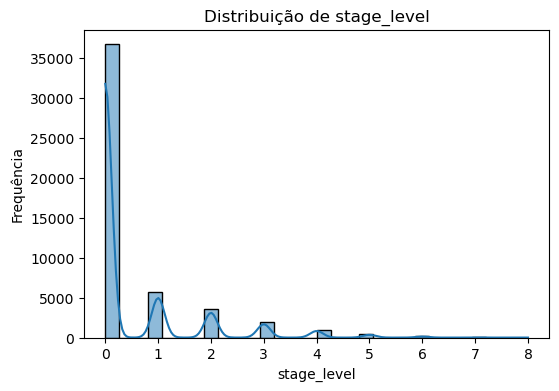

In [59]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_numeric[col], bins=30, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

In [67]:
features = ['funding_total_usd', 'funding_rounds', 'seed', 'venture',
            'debt_financing', 'angel', 'grant', 'private_equity']

df_model = df[features].dropna()

Q1 = df_model.quantile(0.25)
Q3 = df_model.quantile(0.75)
IQR = Q3 - Q1
mask = ~((df_model < (Q1 - 3 * IQR)) | (df_model > (Q3 + 3 * IQR))).any(axis=1)
df_model = df_model[mask]
print(f"Rows after outlier removal: {len(df_model)}")

scaler = RobustScaler()
X = scaler.fit_transform(df_model)

Rows after outlier removal: 21379


In [68]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
df_model = df_model.copy()
df_model['cluster'] = labels

print(df_model['cluster'].value_counts().sort_index())

cluster
0    16767
1     1120
2     1458
3     2034
Name: count, dtype: int64


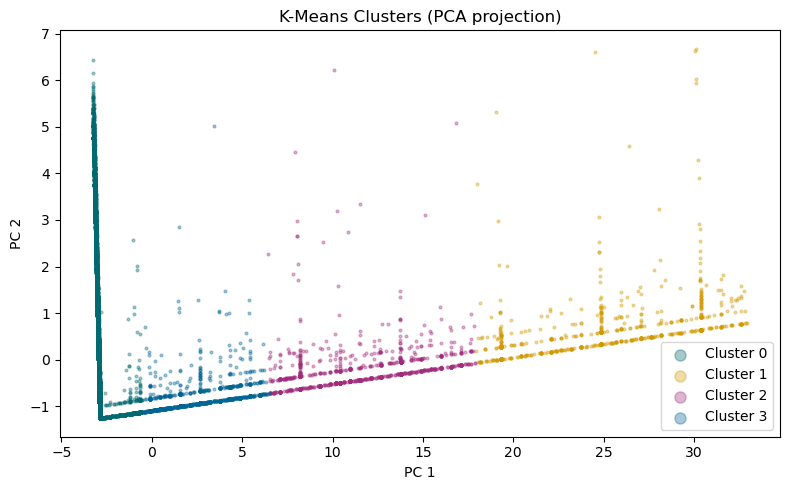

In [69]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#01696f', '#d19900', '#a12c7b', '#006494']
for k in range(K):
    mask = labels == k
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=4, alpha=0.35, color=colors[k], label=f'Cluster {k}')

ax.set_title('K-Means Clusters (PCA projection)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

In [70]:
df[features + ['cluster']] = df_model  
df_model.groupby('cluster')[features].mean().round(0)

,funding_total_usd,funding_rounds,seed,venture,debt_financing,angel,grant,private_equity
cluster,,,,,,,,
0,6294703.0,1.0,756.0,6009630.0,0.0,0.0,0.0,0.0
1,715120.0,1.0,249749.0,458886.0,0.0,0.0,0.0,0.0
2,392816.0,1.0,124961.0,259321.0,0.0,0.0,0.0,0.0
3,155388.0,1.0,44846.0,105926.0,0.0,0.0,0.0,0.0
